In [1]:
import pandas as pd 
import os 
# Define the dataset path using your absolute file path 
dataset_path = r"C:\Users\Lenovo\Downloads\spotify_top_1000_tracks.csv"
# Load dataset 
df = pd.read_csv(dataset_path, encoding="utf-8") 
# Convert release_date and extract year 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
# FIX: We REMOVE the line that tried to create 'duration_min'  
# because it already exists in the CSV file you loaded. 
# (The 'duration_min' column is ready for use!) 
print(" Dataset loaded and basic preprocessing complete!") 
print(df.head(3)) 

 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [2]:
import numpy as np 
# Clean up text columns 
df['track_name'] = df['track_name'].str.strip() 
df['artist'] = df['artist'].str.strip() 
df['album'] = df['album'].str.strip() 
# Convert 'year' to integer 
df['year'] = df['year'].fillna(0).astype(int)

# Drop unnecessary columns 
cols_to_drop = ['spotify_url', 'id', 'release_date'] 
# Check for and add other common audio feature columns if they exist if 'time_signature' in df.columns: 
cols_to_drop.append('time_signature') 
if 'key' in df.columns: 
 cols_to_drop.append('key') 
if 'mode' in df.columns: 
 cols_to_drop.append('mode') 
df = df.drop(columns=cols_to_drop, errors='ignore') 
# Feature Engineering: Tempo Category 
tempo_bins = [0, 100, 140, np.inf] 
tempo_labels = ['Slow', 'Medium', 'Fast'] 
if 'tempo' in df.columns: 
 df['tempo_category'] = pd.cut( # Create tempo category column  df['tempo'], bins=tempo_bins,  
 labels=tempo_labels, right=False 
 ) 
 print("Feature 'tempo_category' created.") 
else: 
 print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.") 
# Remove duplicates 
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first') 
print(f" Data cleaning and feature engineering complete.") 
print(f"Final Row Count after deduplication: {len(df)}") 

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


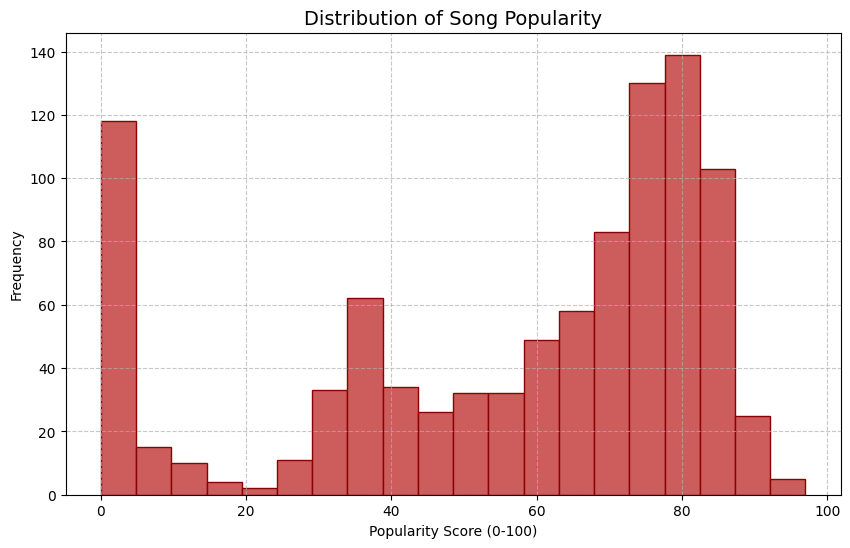

In [7]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 6)) 
plt.hist(df['popularity'], bins=20, color='indianred', 
edgecolor='darkred') 
plt.title('Distribution of Song Popularity', fontsize=14) 
plt.xlabel('Popularity Score (0-100)') 
plt.ylabel('Frequency') 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show() 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3912\1421373015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='plasma')


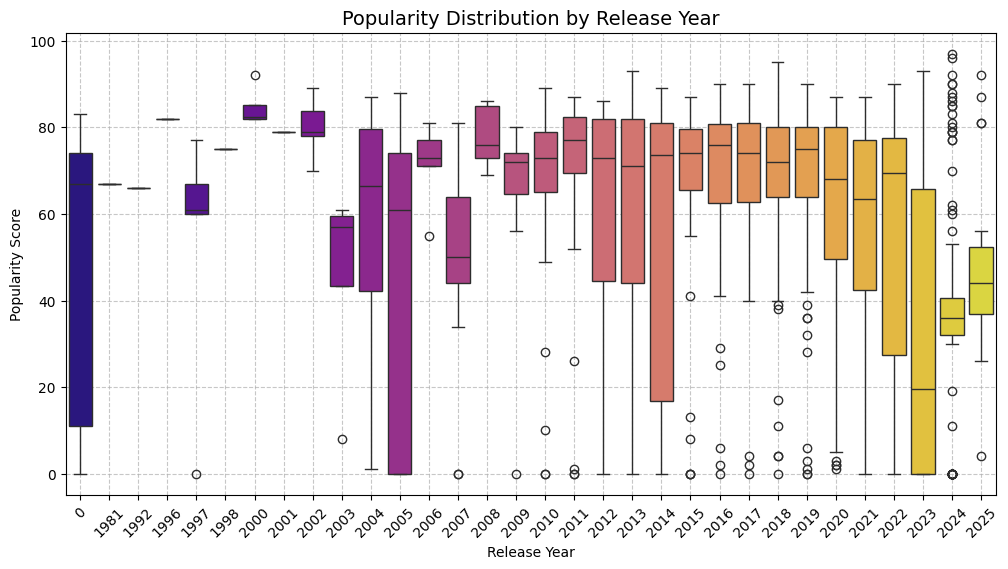

In [10]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(12, 6)) 
sns.boxplot(x='year', y='popularity', data=df, palette='plasma') 
plt.title('Popularity Distribution by Release Year', fontsize=14) 
plt.xlabel('Release Year') 
plt.ylabel('Popularity Score') 
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show() 

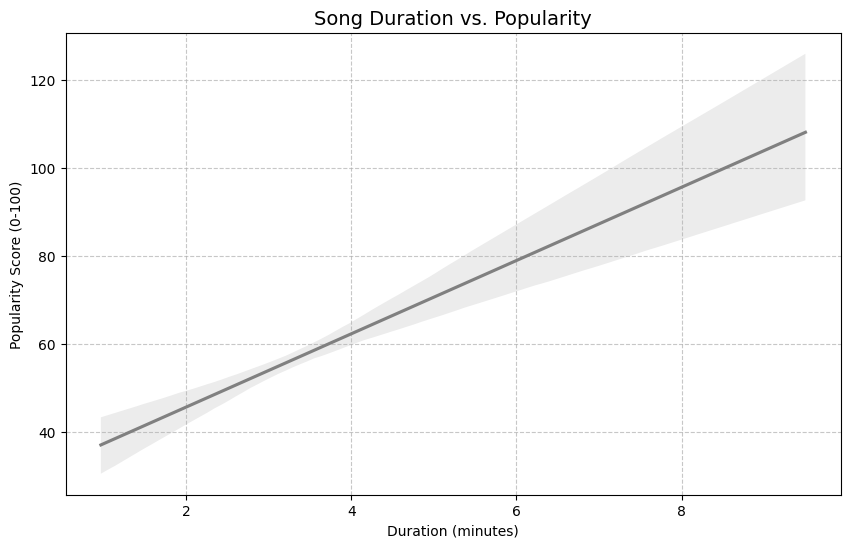

In [14]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(10, 6)) 
sns.regplot(x='duration_min', y='popularity', data=df, scatter=False,  color='grey')  
plt.title('Song Duration vs. Popularity', fontsize=14) 
plt.xlabel('Duration (minutes)') 
plt.ylabel('Popularity Score (0-100)') 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show()

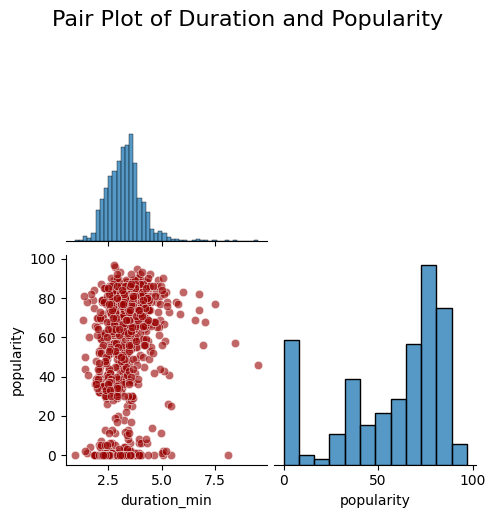

In [15]:
import matplotlib.pyplot as plt 
import seaborn as sns 
# Using only the confirmed numerical columns: 'duration_min' and 'popularity'
key_features = ['duration_min', 'popularity'] 
# We use the simplified sns.pairplot function

sns.pairplot( 
 df[key_features],  
 diag_kind='hist' , 
 corner=True,  
 plot_kws={'alpha': 0.6, 'color': '#990000'} ) 
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16) 
plt.show()  


<Figure size 800x800 with 0 Axes>

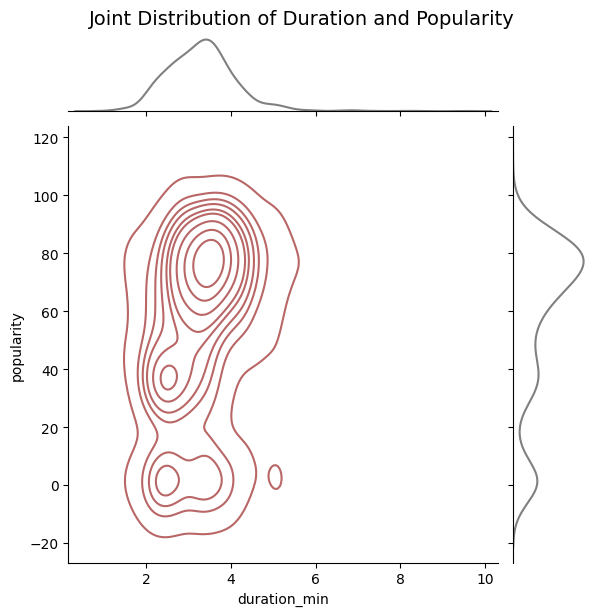

In [20]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(8, 8)) 
sns.jointplot( 
 x='duration_min',  
 y='popularity',  
 data=df,  
 kind='kde',
 marginal_kws={'color': 'gray'},
 joint_kws={'alpha': 0.6, 'color': 'darkred'} 
) 
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02,  fontsize=14) 
plt.show() 

 GIF saved successfully at: c:\Users\Lenovo\OneDrive\Documents\Comprog compilation\Lab7_Data_Visualization_Amosco\yearly_popularity_trend.gif


True

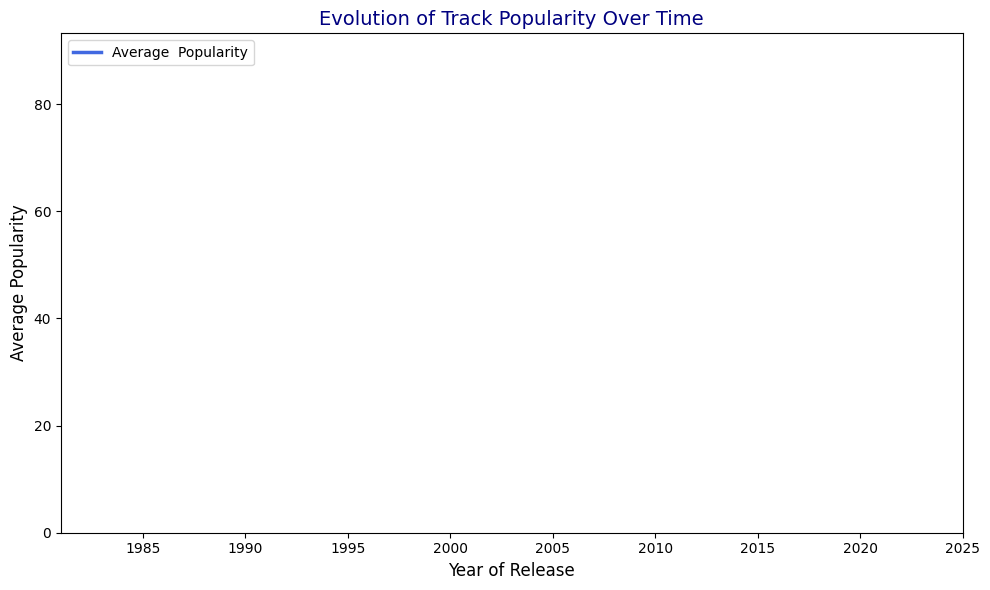

In [5]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation, PillowWriter 
import webbrowser 
# --- Step 1: Load Dataset --- 
csv_files = r"C:\Users\Lenovo\Downloads\spotify_top_1000_tracks.csv"

df = pd.read_csv(csv_files)
# --- Step 2: Data Preparation --- 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce') 
df['year'] = df['release_date'].dt.year 
df = df.dropna(subset=['year'])


# Compute average popularity per year 
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index() 
yearly_popularity = yearly_popularity.sort_values('year') 
# --- Step 3: Initialize the Figure --- 
fig, ax = plt.subplots(figsize=(10, 6)) 
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max()) 
ax.set_ylim(0, yearly_popularity['popularity'].max() * 1.1) 
line, = ax.plot([], [], color='royalblue', linewidth=2.5, label='Average  Popularity') 
ax.set_title("Evolution of Track Popularity Over Time", fontsize=14, color='navy') 
ax.set_xlabel("Year of Release", fontsize=12) 
ax.set_ylabel("Average Popularity", fontsize=12) 
ax.legend(loc="upper left") 
plt.tight_layout() 
# --- Step 4: Define Animation Function --- 
def animate(i): 
 x = yearly_popularity['year'][:i] 
 y = yearly_popularity['popularity'][:i] 
 line.set_data(x, y) 
 return line, 
# --- Step 5: Create and Save Animation --- 
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=60,  repeat=False)
# Automatically Save the GIF 
gif_path = os.path.abspath("yearly_popularity_trend.gif") 
ani.save(gif_path, writer=PillowWriter(fps=10)) 
print(f" GIF saved successfully at: {gif_path}") 
# --- Step 6: Open the Saved GIF --- 
webbrowser.open(f"file://{gif_path}")